In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    f1_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/model_features.csv")

FEATURE_COLS = [
    "distance_km", "product_weight_g", "freight_value", "day_of_week",
    "seller_avg_delay_historical", "category_encoded", "state_encoded",
]
X = df[FEATURE_COLS]
y_reg = df["delivery_delay_days"]
y_clf = df["is_late"]

In [2]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 75,689   Test: 18,923


In [3]:
regressor = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1,
)
regressor.fit(X_train, y_reg_train)

reg_preds = regressor.predict(X_test)

mae = mean_absolute_error(y_reg_test, reg_preds)
rmse = np.sqrt(mean_squared_error(y_reg_test, reg_preds))

# naive baseline: always predict the training mean
baseline_pred = np.full_like(y_reg_test, y_reg_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_reg_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_reg_test, baseline_pred))

print(f"Model    -> MAE: {mae:.2f} days   RMSE: {rmse:.2f} days")
print(f"Baseline -> MAE: {baseline_mae:.2f} days   RMSE: {baseline_rmse:.2f} days")
print(f"Improvement over baseline (MAE): {100 * (1 - mae / baseline_mae):.1f}%")

Model    -> MAE: 6.36 days   RMSE: 9.84 days
Baseline -> MAE: 6.85 days   RMSE: 10.35 days
Improvement over baseline (MAE): 7.1%


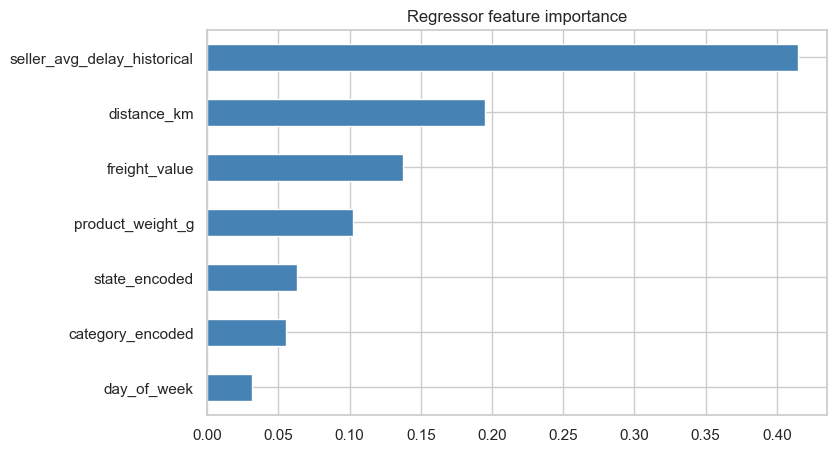

In [5]:
reg_importance = pd.Series(regressor.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
reg_importance.plot.barh(ax=ax, color="steelblue")
ax.set_title("Regressor feature importance")
plt.show()

In [6]:
classifier = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
classifier.fit(X_train, y_clf_train)

clf_preds = classifier.predict(X_test)
clf_proba = classifier.predict_proba(X_test)[:, 1]

f1 = f1_score(y_clf_test, clf_preds)
print(f"F1 score: {f1:.3f}\n")
print(classification_report(y_clf_test, clf_preds, target_names=["on_time", "late"]))

F1 score: 0.224

              precision    recall  f1-score   support

     on_time       0.94      0.76      0.84     17393
        late       0.15      0.47      0.22      1530

    accuracy                           0.74     18923
   macro avg       0.54      0.61      0.53     18923
weighted avg       0.88      0.74      0.79     18923



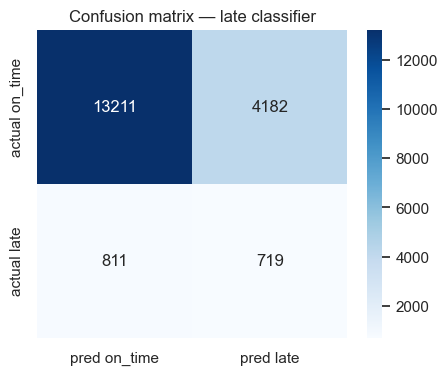

In [7]:
cm = confusion_matrix(y_clf_test, clf_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred on_time", "pred late"],
            yticklabels=["actual on_time", "actual late"], ax=ax)
plt.title("Confusion matrix — late classifier")
plt.show()

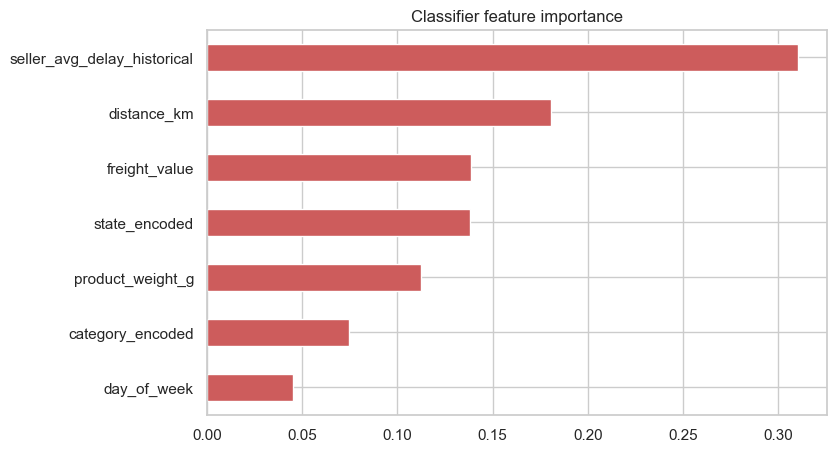

In [8]:
clf_importance = pd.Series(classifier.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
clf_importance.plot.barh(ax=ax, color="indianred")
ax.set_title("Classifier feature importance")
plt.show()

In [9]:
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(regressor, models_dir / "delay_regressor.pkl")
joblib.dump(classifier, models_dir / "late_classifier.pkl")

print("Saved -> models/delay_regressor.pkl")
print("Saved -> models/late_classifier.pkl")

Saved -> models/delay_regressor.pkl
Saved -> models/late_classifier.pkl


In [10]:
import sys
sys.path.append("..")
from src.models import predict_delay

sample_order = {
    "distance_km": 800.0,
    "product_weight_g": 2000.0,
    "freight_value": 35.0,
    "order_purchase_timestamp": "2024-06-01",
    "seller_id": df.index[0],  # any seller id from training data works too
    "product_category_name_english": "electronics_en",
    "customer_state": "SP",
}
import os
os.chdir("..")
print(os.getcwd())  
predict_delay(sample_order)

d:\supply chain delay predictor


{'delay_days': -15.7, 'is_late_probability': 0.231, 'risk_level': 'low'}